# 04 Results Visualization and Screening Demonstration

This notebook creates final result figures and demonstrates a proof-of-concept heat-treatment screening workflow. The screening calculation uses predicted shear strength, required shear load range, and calculated net cross-sectional area.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make paths work whether the notebook is run from the repo root or notebooks folder
NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name == "notebooks":
    REPO_ROOT = NOTEBOOK_DIR.parent
else:
    REPO_ROOT = NOTEBOOK_DIR

DATA_DIR = REPO_ROOT / "data"
FIGURE_DIR = REPO_ROOT / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

processed_path = DATA_DIR / "processed_material_database.csv"

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


## Load data, feature list, and previous results

In [2]:
df = pd.read_csv(processed_path)
feature_info = pd.read_csv(DATA_DIR / "feature_list.csv")
model_results = pd.read_csv(DATA_DIR / "model_results.csv")
model_predictions = pd.read_csv(DATA_DIR / "model_predictions.csv")

numeric_features = feature_info.loc[feature_info["type"] == "numeric", "feature"].tolist()
categorical_features = feature_info.loc[feature_info["type"] == "categorical", "feature"].tolist()

target_col = "MeanShear_ksi"
group_col = "Lot_ID"

display(model_results)
display(model_predictions)


,Model,MAE_ksi,RMSE_ksi,R2
0,Mean baseline,1.677518,1.806403,-0.000752
1,Ridge Regression,0.561218,0.585207,0.894969


,Lot_ID,MeanShear_ksi,TestStage,AgeTemp_F,Pred_Baseline_ksi,Pred_Ridge_ksi,Ridge_Error_ksi,Ridge_AbsError_ksi
0,16347,91.038919,T1,1160,88.812141,91.549475,0.510556,0.510556
1,16347,87.471372,T1A,1180,88.812141,87.128830,-0.342542,0.342542
2,16347,88.097680,T2,1180,88.812141,87.478482,-0.619198,0.619198
3,16827,91.675099,T1,1160,88.869324,90.910850,-0.764248,0.764248
4,16827,87.441029,T1A,1180,88.869324,87.819323,0.378293,0.378293
5,16827,87.320294,T2,1180,88.869324,88.072764,0.752470,0.752470


## Final proof-of-concept results figure

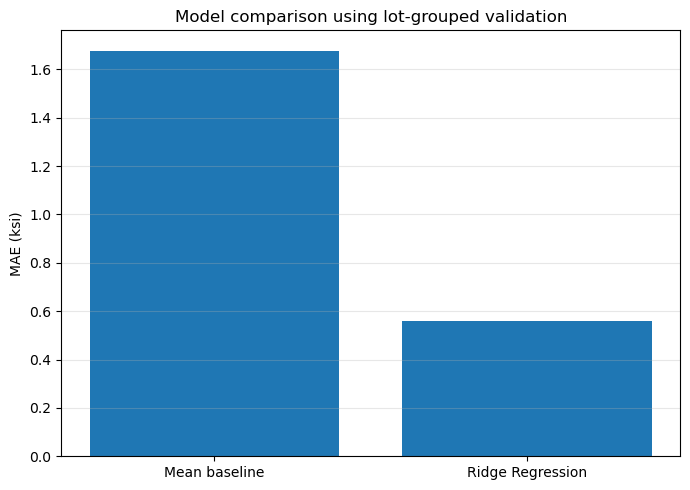

Saved figure to: /Users/SenkoBaby/Desktop/15-5ph-shear-strength-ml/figures/figure4_model_mae_comparison.png


In [3]:
plt.figure(figsize=(7, 5))

plt.bar(model_results["Model"], model_results["MAE_ksi"])

plt.ylabel("MAE (ksi)")
plt.title("Model comparison using lot-grouped validation")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
fig_path = FIGURE_DIR / "figure4_model_mae_comparison.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {fig_path}")


## Train final Ridge model for screening demonstration

This repeats the final model fit so this notebook can run independently after the previous notebooks have produced the processed dataset and feature list.

In [4]:
model_df = df[numeric_features + categorical_features + [target_col, group_col]].copy()

for col in numeric_features:
    model_df[col] = model_df[col].fillna(model_df[col].median())

for col in categorical_features:
    model_df[col] = model_df[col].fillna("Unknown")

model_df = model_df.dropna(subset=[target_col, group_col]).reset_index(drop=True)

X = model_df[numeric_features + categorical_features]
y = model_df[target_col]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

ridge_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", Ridge(alpha=1.0))
    ]
)

ridge_model.fit(X, y)

print("Final proof-of-concept Ridge model fit for screening demonstration.")


Final proof-of-concept Ridge model fit for screening demonstration.


## Screening function

This function screens candidate heat-treatment temperatures and ID/OD combinations, calculates cross-sectional area, predicts shear strength, converts strength to load.  It returns combinations inside the target load range.

In [5]:
def screen_heat_treat_candidates(
    baseline_row,
    target_load_min_lbf,
    target_load_max_lbf,
    id_min,
    id_max,
    od_min,
    od_max,
    candidate_temps=[900, 925, 950, 975, 1000, 1025, 1050, 1100, 1150, 1160, 1180],
    n_id=5,
    n_od=5
):
    results = []

    candidate_ids = np.linspace(id_min, id_max, n_id)
    candidate_ods = np.linspace(od_min, od_max, n_od)

    for temp in candidate_temps:
        for inner_diameter in candidate_ids:
            for outer_diameter in candidate_ods:

                if outer_diameter <= inner_diameter:
                    continue

                net_area = (np.pi / 4) * (outer_diameter**2 - inner_diameter**2)

                candidate = baseline_row.copy()

                if "AgeTemp_F" in candidate.index:
                    candidate["AgeTemp_F"] = temp

                if "Mean_ID_in" in candidate.index:
                    candidate["Mean_ID_in"] = inner_diameter

                if "Mean_OD_in" in candidate.index:
                    candidate["Mean_OD_in"] = outer_diameter

                if "MeanNetArea_in2" in candidate.index:
                    candidate["MeanNetArea_in2"] = net_area

                X_candidate = pd.DataFrame([candidate])[numeric_features + categorical_features]

                predicted_shear_ksi = ridge_model.predict(X_candidate)[0]
                predicted_load_lbf = predicted_shear_ksi * net_area * 1000

                if target_load_min_lbf <= predicted_load_lbf <= target_load_max_lbf:
                    results.append({
                        "AgeTemp_F": temp,
                        "ID_in": inner_diameter,
                        "OD_in": outer_diameter,
                        "NetArea_in2": net_area,
                        "PredShear_ksi": predicted_shear_ksi,
                        "PredLoad_lbf": predicted_load_lbf
                    })

    return pd.DataFrame(results)


## Example screening run

The values below are placeholders for demonstrating the workflow and would be replaced with actual values during implimentation.

In [6]:
baseline_row = X.iloc[0].copy()

target_load_min_lbf = 170000
target_load_max_lbf = 190000

screen_results = screen_heat_treat_candidates(
    baseline_row=baseline_row,
    target_load_min_lbf=target_load_min_lbf,
    target_load_max_lbf=target_load_max_lbf,
    id_min=0.700,
    id_max=0.750,
    od_min=1.330,
    od_max=1.360
)

print("Candidate heat-treatment / geometry combinations:")
display(screen_results)

screen_results.to_csv(DATA_DIR / "screening_results.csv", index=False)
print("Saved screening results to data/screening_results.csv")


Candidate heat-treatment / geometry combinations:


""


Saved screening results to data/screening_results.csv


## Screening visualization

In [7]:
if len(screen_results) > 0:

    plt.figure(figsize=(7, 5))

    plt.scatter(
        screen_results["AgeTemp_F"],
        screen_results["PredLoad_lbf"],
        s=80
    )

    plt.axhline(target_load_min_lbf, linestyle="--", label="Target minimum")
    plt.axhline(target_load_max_lbf, linestyle="--", label="Target maximum")

    plt.xlabel("Age temperature (°F)")
    plt.ylabel("Predicted shear load (lbf)")
    plt.title("Proof-of-concept heat-treatment screening")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    fig_path = FIGURE_DIR / "figure4_screening_results.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Saved figure to: {fig_path}")

else:
    print("No candidate combinations met the target load range.")


No candidate combinations met the target load range.


## Interpretation note

This screening output is a proof-of-concept due to the lack of available data.  The current dataset is too small for strong predictive claims, but the workflow demonstartes how the model can eventually connect required shear load, cross-sectional area, and candidate heat-treatment temperature.